In [1]:
# 1. Install  libraries
!pip install -q  accelerate transformers ftfy bitsandbytes peft
# 2. Clone the official training scripts
!git clone https://github.com/huggingface/diffusers.git
!pip install git+https://github.com/huggingface/diffusers.git

# 3. Setup Accelerate
from accelerate.utils import write_basic_config
write_basic_config()

fatal: destination path 'diffusers' already exists and is not an empty directory.
  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-y36daqs_
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-y36daqs_
  Resolved https://github.com/huggingface/diffusers.git to commit 48f39c2d59e8db444cb37f91e72413a1db9a2dd6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Configuration already exists at /root/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.


False

In [2]:
import os
import shutil
import json
import pandas as pd
import os
import zipfile
import diffusers

In [3]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [4]:
zip_path     = '/content/drive/MyDrive/CelebAMask-HQ.zip'
extract_path = '/content/celeba_data/'

if not os.path.exists(extract_path):
    print('Extracting to local storage...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print('Extraction complete.')
else:
    print('Dataset already extracted — skipping.')


Dataset already extracted — skipping.


In [5]:
print(os.listdir('/content/celeba_data/CelebAMask-HQ/'))

['CelebA-HQ-img', 'CelebAMask-HQ-mask-anno', 'CelebA-HQ-to-CelebA-mapping.txt', 'CelebAMask-HQ-pose-anno.txt', '.DS_Store', 'CelebAMask-HQ-attribute-anno.txt', 'README.txt']


In [6]:
# Load the HQ↔original bridge mapping
mapping_df = pd.read_csv(
    '/content/celeba_data/CelebAMask-HQ/CelebA-HQ-to-CelebA-mapping.txt',
    sep=r'\s+', header=0
)

# Load original identity labels
identity_df = pd.read_csv(
    '/content/drive/MyDrive/identity_CelebA.txt',
    sep=r'\s+', header=None, names=['orig_file', 'person_id']
)

# Merge and build HQ filename column
merged_df = pd.merge(mapping_df, identity_df, on='orig_file')
merged_df['hq_filename'] = merged_df['idx'].apply(lambda x: f'{x}.jpg')
final_mapping = merged_df[['hq_filename', 'person_id']]

print(final_mapping.head())

  hq_filename  person_id
0       0.jpg       7423
1       1.jpg       7319
2       2.jpg       6632
3       3.jpg       3338
4       4.jpg       9178


In [7]:
# Count how many high-quality images each person has
id_counts = final_mapping['person_id'].value_counts()

# Filter for people with at least 5 images
candidates = id_counts[id_counts >= 5].index.tolist()

print(f"Total candidates available for 5-shot: {len(candidates)}")
# Pick the first 3 IDs
selected_ids = candidates[:3]
print(f"Selected Person IDs for experiments: {selected_ids}")

Total candidates available for 5-shot: 2398
Selected Person IDs for experiments: [861, 5247, 5884]


In [8]:
# Settings
base_img_path = '/content/celeba_data/CelebAMask-HQ/CelebA-HQ-img/'
target_person = selected_ids[0]

# Path for 1-shot only
path_1shot = f'/content/train_{target_person}_1shot'
os.makedirs(path_1shot, exist_ok=True)

# Get image filenames for this person
person_images = final_mapping[final_mapping['person_id'] == target_person]['hq_filename'].tolist()

# Copy 1 image for 1-shot
dst = os.path.join(path_1shot, "img_0.jpg")
shutil.copy(os.path.join(base_img_path, person_images[0]), dst)

# Verify
print(f"Folder contents: {os.listdir(path_1shot)}")
print(f"Source image: {person_images[0]}")
print(f"Copied to: {dst}")
print(f"Folders prepared for Person {target_person}")

Folder contents: ['metadata.jsonl', 'img_0.jpg']
Source image: 183.jpg
Copied to: /content/train_861_1shot/img_0.jpg
Folders prepared for Person 861


In [9]:
def create_metadata(folder_path, trigger_phrase="a photo of sks_person"):
    metadata_file = os.path.join(folder_path, 'metadata.jsonl')
    with open(metadata_file, 'w') as f:
        for img_name in os.listdir(folder_path):
            if img_name.endswith('.jpg'):
                line = {"file_name": img_name, "text": trigger_phrase}
                f.write(json.dumps(line) + '\n')

create_metadata(path_1shot)
print("Metadata files created.")
print(path_1shot)

Metadata files created.
/content/train_861_1shot


In [10]:
%cd diffusers/examples/text_to_image


/content/diffusers/examples/text_to_image


In [11]:
# Configuration variables
!pip install torchao==0.16.0
OUTPUT_DIR = f"/content/lora_output_{target_person}"
RANK = 8

!accelerate launch train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/content/train_861_1shot" \
  --resolution=256 \
  --random_flip \
  --train_batch_size=1 \
  --num_train_epochs=500 \
  --checkpointing_steps=500 \
  --learning_rate=1e-4 \
  --lr_scheduler=constant \
  --lr_warmup_steps=0 \
  --seed=42 \
  --output_dir="/content/lora_output_861" \
  --rank=8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 107.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
05/10/2026 13:55:01 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
05/10/2026 13

In [12]:
from diffusers import StableDiffusionPipeline
import torch

#  Load the base model
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16,safety_checker=None,
    requires_safety_checker=False).to("cuda")

#  Load the trained LoRA weights
pipe.load_lora_weights(OUTPUT_DIR)


fixed_prompts = [
    "A high‑quality studio headshot of sks_person, facing the camera, neutral expression, plain grey background, soft even lighting, 35mm lens, realistic skin texture.",
    "A high‑quality studio portrait of sks_person, upper body, looking slightly to the left, neutral expression, plain grey background, soft directional lighting from the right.",
    "A high‑quality portrait of sks_person, facing the camera, big natural smile, teeth visible, blurred indoor background, warm soft lighting.",
    "A cinematic close‑up of sks_person, neutral expression, dark background, strong side lighting creating shadows on half of the face, high contrast, realistic skin texture.",
    "A realistic outdoor portrait of sks_person, upper body, standing in a city street during the day, soft natural daylight, shallow depth of field, background slightly blurred.",
    "A realistic outdoor portrait of sks_person, upper body, standing in a city at sunset, warm orange light on the face, soft bokeh lights in the background.",
    "A realistic portrait of sks_person, sitting indoors near a window, soft daylight from the side, bookshelf in the background, natural colours, medium shot.",
    "A realistic portrait of sks_person, facing the camera, wearing simple glasses, neutral expression, plain light background, soft studio lighting." ,
    "A realistic half‑body photo of sks_person, standing, facing the camera, neutral expression, simple indoor background, soft even lighting.",
    "A realistic portrait of sks_person, varied pose and expression, random indoor or outdoor background, natural lighting, photographic style."
]

#Generate 300 images
results_dir = f"/content/generated_{target_person}"
os.makedirs(results_dir, exist_ok=True)

image_count = 0
for prompt in fixed_prompts:
    for i in range(30):
        image = pipe(prompt, num_inference_steps=30).images[0]
        image.save(f"{results_dir}/img_{image_count}.png")
        image_count += 1

print(f"Generated {image_count} images for evaluation.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Generated 300 images for evaluation.


In [19]:
!pip install -q clean-fid
from cleanfid import fid
import random

real_dir = f"/content/real_test_{target_person}"
os.remove('/content/real_test_861')
os.makedirs('/content/real_test_861', exist_ok=True)

    # Copy all identity images first
person_imgs = final_mapping[final_mapping['person_id'] == target_person]['hq_filename'].tolist()
for fn in person_imgs:
        shutil.copy(os.path.join(base_img_path, fn), real_dir)

# Pad with random faces
if len(person_imgs) < 300:
        all_imgs = [f for f in os.listdir(base_img_path) if f.endswith('.jpg')]
        # exclude identity images to avoid duplicates
        all_imgs = [f for f in all_imgs if f not in person_imgs]
        extras = random.sample(all_imgs, 300 - len(person_imgs))
        for fn in extras:
            shutil.copy(os.path.join(base_img_path, fn), real_dir)

        print(f"Real images built: {len(os.listdir(real_dir))}")
else:
        print(f"Real images already exist: {len(os.listdir(real_dir))} — skipping copy")

# Compute FID
fid_score = fid.compute_fid(results_dir, real_dir)
print(f"FID → {fid_score:.2f}")

Real images built: 300
compute FID between two folders
Found 300 images in the folder /content/generated_861


FID generated_861 : 100%|██████████| 10/10 [00:05<00:00,  1.70it/s]


Found 300 images in the folder /content/real_test_861


FID real_test_861 : 100%|██████████| 10/10 [00:06<00:00,  1.59it/s]


FID → 141.73


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 104.0 MB/s eta 0:00:00
26-05-10 14:08:51 - Directory /root/.deepface has been created
26-05-10 14:08:51 - Directory /root/.deepface/weights has been created
26-05-10 14:08:53 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:00<00:00, 179MB/s]
FRS: 100%|██████████| 300/300 [01:01<00:00,  4.85it/s]

FRS → mean=0.4005  std=0.0867


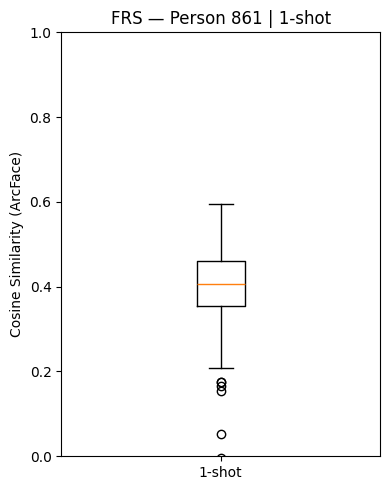

In [15]:
!pip install deepface
from deepface import DeepFace
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

def get_embedding(img_path):
    try:
        result = DeepFace.represent(img_path, model_name="ArcFace", enforce_detection=False)
        return np.array(result[0]["embedding"])
    except:
        return None

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a) + 1e-8)
    b = b / (np.linalg.norm(b) + 1e-8)
    return float(np.dot(a, b))

# Reference embedding
ref_files = [f for f in os.listdir('/content/train_861_1shot') if f.lower().endswith(('.jpg', '.png'))]
ref_emb   = get_embedding(os.path.join('/content/train_861_1shot', ref_files[0]))

# Cosine similarity for all generated images
sims = []
for fn in tqdm(os.listdir(results_dir), desc="FRS"):
    if fn.lower().endswith('.png'):
        emb = get_embedding(os.path.join(results_dir, fn))
        if emb is not None:
            sims.append(cosine_sim(emb, ref_emb))

print(f"FRS → mean={np.mean(sims):.4f}  std={np.std(sims):.4f}")

# Boxplot
plt.figure(figsize=(4, 5))
plt.boxplot(sims, labels=["1-shot"])
plt.title(f"FRS — Person {target_person} | 1-shot")
plt.ylabel("Cosine Similarity (ArcFace)")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("/content/frs_boxplot.png", dpi=150)
plt.show()

In [20]:
#  LPIPS Diversity
!pip install -q lpips

import lpips
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from tqdm import tqdm


loss_fn = lpips.LPIPS(net='alex').cuda()

def load_tensor(img_path, size=256):
    img = Image.open(img_path).convert('RGB').resize((size, size))
    t   = transforms.ToTensor()(img) * 2 - 1
    return t.unsqueeze(0).cuda()

gen_files = [os.path.join(results_dir, f)
             for f in os.listdir(results_dir) if f.lower().endswith('.png')]

rng  = np.random.default_rng(42)
idxs = rng.choice(len(gen_files), size=(200, 2), replace=True)
dists = []
for i, j in tqdm(idxs, desc="LPIPS pairs"):
    if i == j:
        continue
    with torch.no_grad():
        d = loss_fn(load_tensor(gen_files[i]), load_tensor(gen_files[j]))
    dists.append(d.item())

print(f"LPIPS Diversity → {np.mean(dists):.4f} ")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


LPIPS pairs: 100%|██████████| 200/200 [00:06<00:00, 29.34it/s]

LPIPS Diversity → 0.4775 


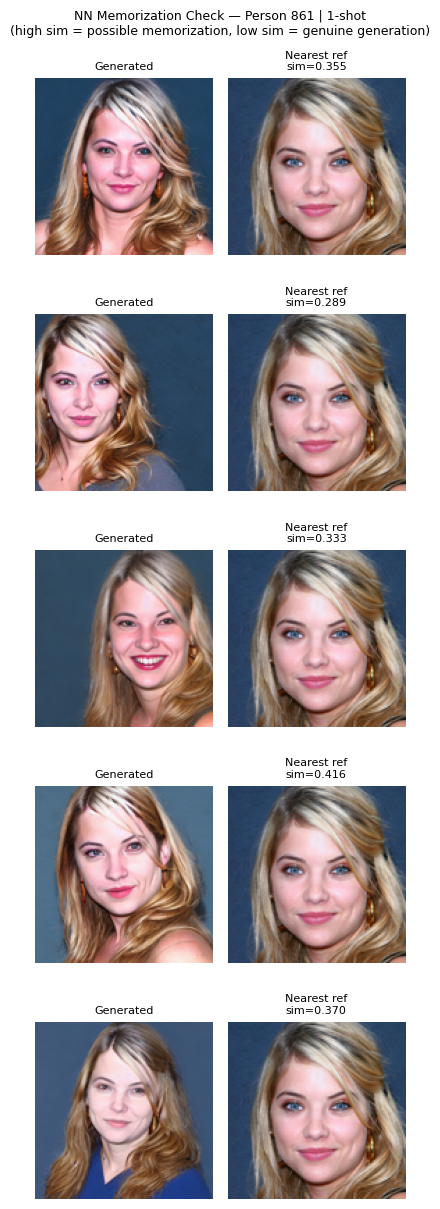

In [21]:
# Nearest-Neighbour Memorization
import random
from PIL import Image
import matplotlib.pyplot as plt
# Get reference embeddings
ref_files_full = [os.path.join('/content/train_861_1shot', f)
                  for f in os.listdir('/content/train_861_1shot')
                  if f.lower().endswith(('.jpg', '.png'))]
ref_embs = [(fp, get_embedding(fp)) for fp in ref_files_full]
ref_embs = [(fp, e) for fp, e in ref_embs if e is not None]

# Sample 5 random generated images
gen_files = [os.path.join(results_dir, f)
             for f in os.listdir(results_dir) if f.lower().endswith('.png')]
sampled = random.sample(gen_files, min(5, len(gen_files)))

fig, axes = plt.subplots(len(sampled), 2, figsize=(4, 2.5 * len(sampled)))

for row, gen_path in enumerate(sampled):
    gen_emb = get_embedding(gen_path)
    if gen_emb is None:
        continue

    # compute similarity for each reference
    similarities = [(fp, float(cosine_sim(gen_emb, e))) for fp, e in ref_embs]

    # find nearest neighbour
    nn_path, nn_sim = max(similarities, key=lambda x: x[1])

    axes[row][0].imshow(Image.open(gen_path).resize((128, 128)))
    axes[row][0].set_title("Generated", fontsize=8)
    axes[row][0].axis('off')

    axes[row][1].imshow(Image.open(nn_path).resize((128, 128)))
    axes[row][1].set_title(f"Nearest ref\nsim={nn_sim:.3f}", fontsize=8)
    axes[row][1].axis('off')

plt.suptitle(f"NN Memorization Check — Person {target_person} | 1-shot\n"
             f"(high sim = possible memorization, low sim = genuine generation)",
             fontsize=9)
plt.tight_layout()
plt.savefig("/content/Memorization_check.png", dpi=150)
plt.show()